<a href="https://colab.research.google.com/github/Lavish05563/california-housing-regression/blob/main/AI_ML_Task4_Classification_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHASE 1: DATA ACQUISITION & PREPROCESSING
[INFO] Dataset loaded successfully.
[INFO] Feature matrix shape : (569, 30)
[INFO] Target distribution  : Class 0 (Malignant) = 212 | Class 1 (Benign) = 357
[INFO] Stratified train-test split executed (80% train, 20% test).
[INFO] Feature scaling completed successfully.

PHASE 2: MODEL TRAINING & METRIC EVALUATION

--> Training Baseline Logistic Regression Model...
--> Training Balanced Logistic Regression Model (Class-Weighted)...
--> Training Baseline Decision Tree Classifier...

PHASE 3: MANDATORY DISCOVERY REPORTS & COMPARISONS

########################################
### PERFORMANCE REPORT: BASELINE LOGISTIC REGRESSION
########################################

[Visual Confusion Matrix Layout]
                 Predicted Malignant(0)   Predicted Benign(1)
Actual Malignant(0)        41                       1         
Actual Benign(1)           1                        71        

[Detailed Classification Metrics]
                     precis

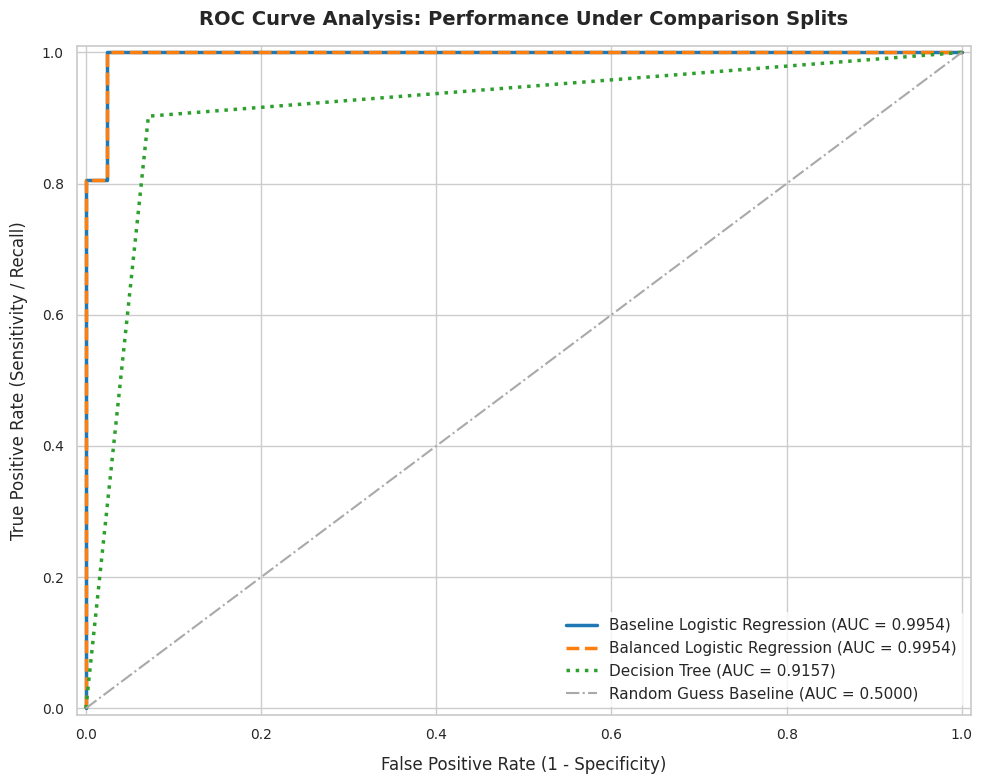

[SUCCESS] Complete processing complete.
[SUCCESS] High-resolution visualization exported safely as: 'classification_roc_curve.png'


In [1]:
# ==============================================================================
# MAINCRAFTS TECHNOLOGY - AI & ML TASK 4
# FILE NAME: AI_ML_Task4_Classification_Evaluation.ipynb
# DESCRIPTION: Comprehensive Binary Classification Pipeline & Evaluation Suite
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Configure elegant plotting environment settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 8),
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# ==============================================================================
# PHASE 1: DATA ACQUISITION & PREPROCESSING
# ==============================================================================
print("="*80)
print("PHASE 1: DATA ACQUISITION & PREPROCESSING")
print("="*80)

# Load the built-in breast cancer diagnostic dataset
raw_data = load_breast_cancer()
X = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
y = raw_data.target

print(f"[INFO] Dataset loaded successfully.")
print(f"[INFO] Feature matrix shape : {X.shape}")
print(f"[INFO] Target distribution  : Class 0 (Malignant) = {np.sum(y == 0)} | Class 1 (Benign) = {np.sum(y == 1)}")

# Partition data using a stratified split to anchor class balance ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"[INFO] Stratified train-test split executed (80% train, 20% test).")

# Standardize features (Z-score normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"[INFO] Feature scaling completed successfully.\n")


# ==============================================================================
# PHASE 2: MODEL TRAINING & ARTIFACT GENERATION
# ==============================================================================
print("="*80)
print("PHASE 2: MODEL TRAINING & METRIC EVALUATION")
print("="*80)

# Dictionary to hold target evaluation probabilities for the final ROC curve
model_probabilities = {}
model_predictions = {}

# --- 1. Baseline Logistic Regression ---
print("\n--> Training Baseline Logistic Regression Model...")
baseline_lr = LogisticRegression(max_iter=1000, random_state=42)
baseline_lr.fit(X_train_scaled, y_train)
model_predictions['Baseline Logistic Regression'] = baseline_lr.predict(X_test_scaled)
model_probabilities['Baseline Logistic Regression'] = baseline_lr.predict_proba(X_test_scaled)[:, 1]

# --- 2. Balanced Logistic Regression (Handling Class Imbalance) ---
print("--> Training Balanced Logistic Regression Model (Class-Weighted)...")
balanced_lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
balanced_lr.fit(X_train_scaled, y_train)
model_predictions['Balanced Logistic Regression'] = balanced_lr.predict(X_test_scaled)
model_probabilities['Balanced Logistic Regression'] = balanced_lr.predict_proba(X_test_scaled)[:, 1]

# --- 3. Decision Tree Classifier ---
print("--> Training Baseline Decision Tree Classifier...")
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train) # Tree models are invariant to scale features
model_predictions['Decision Tree'] = decision_tree.predict(X_test)
model_probabilities['Decision Tree'] = decision_tree.predict_proba(X_test)[:, 1]


# ==============================================================================
# PHASE 3: EVALUATION & ANALYSIS PRINT OUTS (DELIVERABLE 2 & 4)
# ==============================================================================
print("\n" + "="*80)
print("PHASE 3: MANDATORY DISCOVERY REPORTS & COMPARISONS")
print("="*80)

comparison_records = []

for name, preds in model_predictions.items():
    print(f"\n{'#'*40}\n### PERFORMANCE REPORT: {name.upper()}\n{'#'*40}")

    # Generate Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    # Calculate explicit structural metrics for comparison reporting
    report_dict = classification_report(y_test, preds, output_dict=True)
    malignant_recall = report_dict['0']['recall']
    malignant_precision = report_dict['0']['precision']
    f1_macro = report_dict['macro avg']['f1-score']
    acc = report_dict['accuracy']
    auc_val = roc_auc_score(y_test, model_probabilities[name])

    comparison_records.append({
        "Model Framework": name,
        "Accuracy": round(acc, 4),
        "Malignant Precision": round(malignant_precision, 4),
        "Malignant Recall (Sensitivity)": round(malignant_recall, 4),
        "Macro F1-Score": round(f1_macro, 4),
        "ROC-AUC Score": round(auc_val, 4)
    })

    # Print formatted matrix output
    print("\n[Visual Confusion Matrix Layout]")
    print(f"                 Predicted Malignant(0)   Predicted Benign(1)")
    print(f"Actual Malignant(0)        {tn:<10}               {fp:<10}")
    print(f"Actual Benign(1)           {fn:<10}               {tp:<10}")

    print("\n[Detailed Classification Metrics]")
    print(classification_report(y_test, preds, target_names=['Malignant (Class 0)', 'Benign (Class 1)']))

# Print out final comparison results dataframe directly into output log
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY SUMMARY")
print("="*80)
df_comparison = pd.DataFrame(comparison_records)
print(df_comparison.to_string(index=False))


# ==============================================================================
# PHASE 4: ROC/AUC PLOT GRAPHING SUITE (DELIVERABLE 3)
# ==============================================================================
print("\n" + "="*80)
print("PHASE 4: VISUAL GRAPH DATA GENERATION")
print("="*80)
print("[INFO] Building and displaying comparison evaluation plots...")

fig, ax = plt.subplots(figsize=(10, 8))

# Map line style design variants for easy identification
linestyles = {
    'Baseline Logistic Regression': ('#1f77b4', '-'),
    'Balanced Logistic Regression': ('#ff7f0e', '--'),
    'Decision Tree': ('#2ca02c', ':')
}

for name, probs in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    color, style = linestyles[name]

    ax.plot(
        fpr, tpr,
        label=f"{name} (AUC = {auc_score:.4f})",
        color=color,
        linestyle=style,
        linewidth=2.5
    )

# Add baseline diagonal reference line
ax.plot([0, 1], [0, 1], color='darkgray', linestyle='-.', label='Random Guess Baseline (AUC = 0.5000)')

# Refine plot structure boundaries
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_xlabel('False Positive Rate (1 - Specificity)', labelpad=10)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', labelpad=10)
ax.set_title('ROC Curve Analysis: Performance Under Comparison Splits', pad=15, fontweight='bold')
ax.legend(loc="lower right", frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()

# Save image file to your active working folder path automatically
output_plot_path = 'classification_roc_curve.png'
plt.savefig(output_plot_path, dpi=300)
plt.show()

print(f"[SUCCESS] Complete processing complete.")
print(f"[SUCCESS] High-resolution visualization exported safely as: '{output_plot_path}'")
print("="*80)